In [1]:
import matplotlib.pyplot as plt
from torch.profiler import profile, ProfilerActivity
from cubes import get_cube
from utils import profile_and_capture

In [2]:
device = "cpu"
order = "1"
results = {}

In [3]:
header_mem = " Peak VRAM" if (device == "cuda") else "  Peak RAM"

print(f"|  N  |     DOFs |     Setup | FWD Solve | BWD Solve | {header_mem} |")
print("| --- | -------- | --------- | --------- | --------- | ---------- |")

for N in [10, 20, 30, 40, 50, 60, 70, 80]:
    cmd = ["python", "cubes.py", "-N", str(N), "-device", device, "-order", order]
    mem_data, internal_clock = profile_and_capture(cmd)
    mem_usage = [r for _, r in mem_data]
    setup_t = internal_clock["SETUP_DONE"] - internal_clock["START"]
    fwd_t = internal_clock["FWD_DONE"] - internal_clock["SETUP_DONE"]
    bwd_t = internal_clock["BWD_DONE"] - internal_clock["FWD_DONE"]
    print(
        f"| {N:3d} | {3*N**3:8d} | {setup_t:8.2f}s | {fwd_t:8.2f}s | {bwd_t:8.2f}s "
        f"| {max(mem_usage):8.1f}MB |"
    )
    results[N] = (mem_data, internal_clock)

|  N  |     DOFs |     Setup | FWD Solve | BWD Solve |   Peak RAM |
| --- | -------- | --------- | --------- | --------- | ---------- |
|  10 |     3000 |     0.02s |     0.16s |     0.36s |    488.9MB |
|  20 |    24000 |     0.15s |     0.74s |     0.34s |    892.1MB |
|  30 |    81000 |     0.53s |     2.80s |     0.86s |   1955.7MB |
|  40 |   192000 |     1.24s |     6.48s |     1.53s |   3056.3MB |
|  50 |   375000 |     2.43s |    13.32s |     3.06s |   5210.3MB |
|  60 |   648000 |     4.52s |    25.02s |     5.35s |   6402.4MB |
|  70 |  1029000 |     8.73s |    45.24s |     9.19s |   7620.5MB |
|  80 |  1536000 |    14.11s |    72.96s |    14.51s |   9854.7MB |


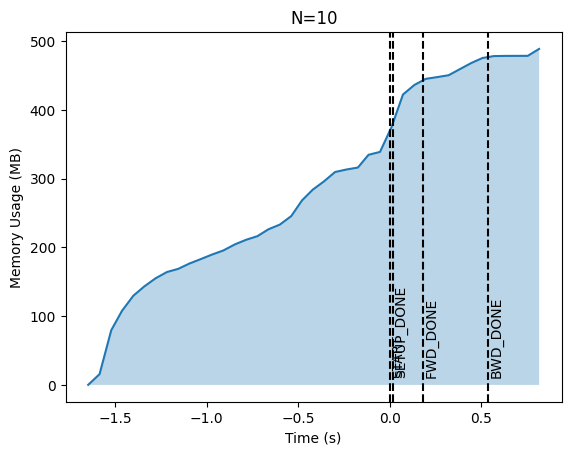

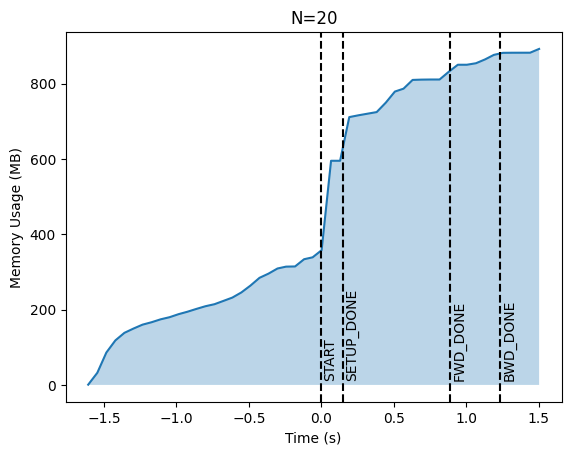

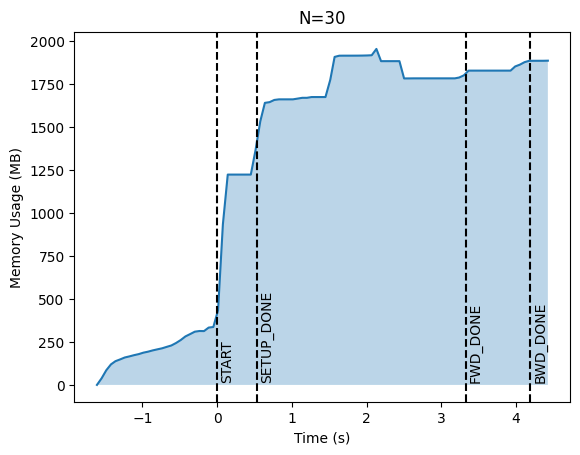

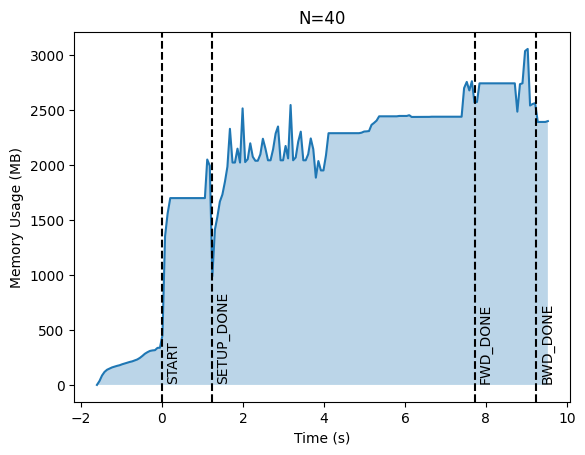

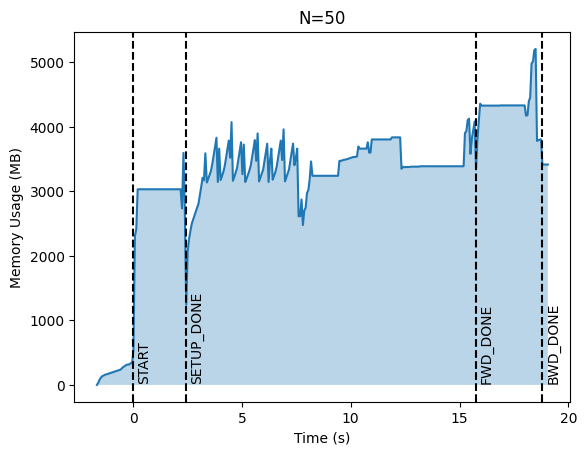

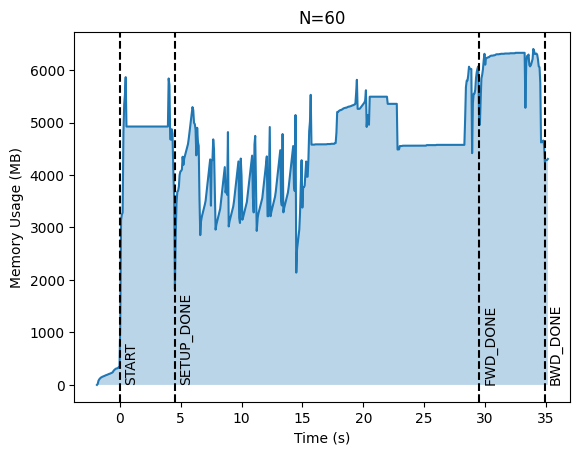

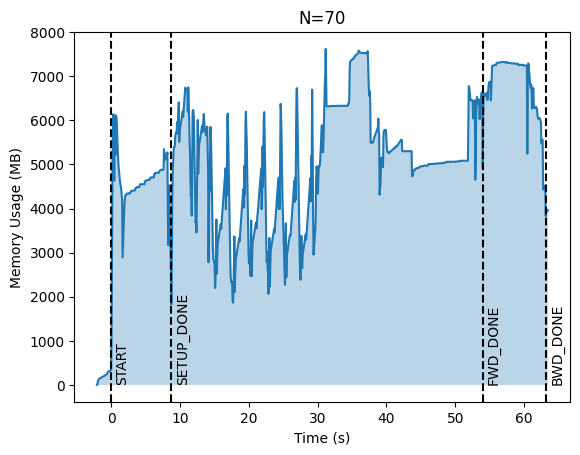

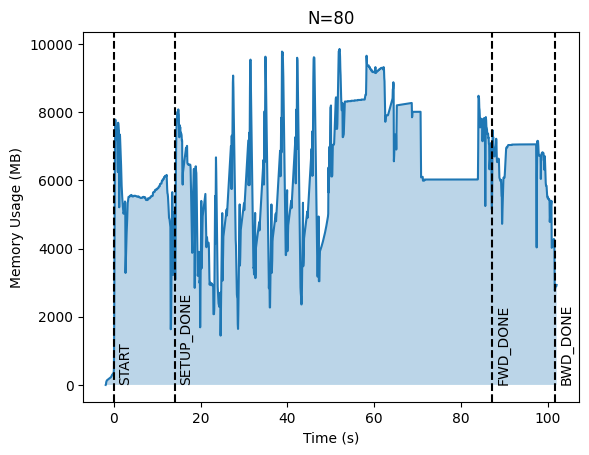

In [4]:
for N, (mem_data, internal_clock) in results.items():
    t0 = internal_clock["START"]
    times = [t - t0 for t, _ in mem_data]
    mem_usage = [r for _, r in mem_data]
    plt.plot(times, mem_usage)
    plt.fill_between(times, mem_usage, alpha=0.3)
    for tag, abs_ts in internal_clock.items():
        relative_ts = abs_ts - t0
        plt.axvline(x=relative_ts, color="black", linestyle="--")
        plt.text(
            relative_ts + 0.01 * max(times),
            10,
            tag,
            rotation=90,
            verticalalignment="bottom",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Memory Usage (MB)")
    plt.title(f"N={N}")
    plt.show()

In [5]:
import cProfile
import pstats


def test():
    cube = get_cube(50)
    cube.solve()


cProfile.run("test()", "stats")
p = pstats.Stats("stats")
print(p.sort_stats("time").print_stats(10))

Fri Apr 10 13:40:16 2026    stats

         30675 function calls (30414 primitive calls) in 16.774 seconds

   Ordered by: internal time
   List reduced from 429 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       80    4.875    0.061    4.875    0.061 {built-in method torch.einsum}
       96    2.224    0.023    2.224    0.023 {built-in method pyamg.amg_core.relaxation.gauss_seidel}
        1    2.197    2.197    2.197    2.197 {built-in method torch._unique2}
       77    1.623    0.021    1.623    0.021 {built-in method scipy.sparse._sparsetools.csr_matvec}
        8    1.388    0.174    1.388    0.174 {built-in method scipy.sparse._sparsetools.bsr_matmat}
        3    0.694    0.231    6.365    2.122 /Users/meyernil/Code/torch-fem/src/torchfem/base.py:607(integrate_material)
      156    0.478    0.003    0.478    0.003 {built-in method scipy.sparse._sparsetools.bsr_matvec}
        4    0.278    0.069    0.278    0.069 {buil

In [6]:
with profile(
    activities=[ProfilerActivity.CPU],
    profile_memory=True,
    record_shapes=True,
) as prof:
    cube = get_cube(20)
    solution = cube.solve()


# Export trace to Chrome Trace format (this can be opened in chrome://tracing or https://ui.perfetto.dev/)
prof.export_chrome_trace("trace.json")
# Print profiler results
print(prof.key_averages().table(sort_by="cpu_memory_usage", row_limit=10))

/Users/meyernil/miniforge3/envs/torchfem/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


--------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
--------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                      aten::einsum         0.40%       5.332ms        50.09%     672.597ms       8.407ms     579.45 MB    -181.27 MB            80  
                                         aten::mul         1.62%      21.765ms         1.64%      22.005ms      75.880us     564.24 MB     562.57 MB           290  
                                       aten::empty         0.02%     302.888us         0.02%     302.888us       1.967us     520.43 MB     520.43 MB           154  
          